In [1]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os
from pathlib import Path

In [2]:
root_output_directory = "/Net/Groups/BSI/scratch/ppapastefanou/simulations/SimPHony/swiss_cc"
#root_output_directory = "/Net/Groups/BSI/scratch/ppapastefanou/simulations/SimPHony/"


In [3]:
scenario_name = "45-2_LHS_high_wcontvar_full"
#scenario_name = "45-3_LHS_no_gstem_full"
input_path = os.path.join(root_output_directory, scenario_name, 'input')
output_path = os.path.join(root_output_directory, scenario_name, 'output')
post_path = os.path.join(root_output_directory, scenario_name, 'post')

In [4]:
varsy = ['psi_leaf_50_close', 'd_50_close','stem_hydraulic_capacitance', 'stem_hydraulic_capacitance_res', 'k_xylem_sat','huber_value',  'leaf_hydraulic_capacitance', 
        'psi50_xylem' , 'psi88_xylem','alpha','g0', 'g1', 'k_soil_sat0', 'psi_soil_sat0','jackson_root_beta',  'pore_0',  'root_area_index', 'wcont_sigma_deviation','g_stem_res', 'vmax25' , 'jmax25']
#vars_plant = ['stem_hydraulic_capacitance', 'k_xylem_sat','huber_value', 'leaf_hydraulic_capacitance', 'psi50_xylem' ,'g0','jackson_root_beta', 'alpha']

In [5]:
dead_ids =[0,3,6,7]
for did in dead_ids:
    df = pd.read_csv(os.path.join(post_path, f"parameters_best_{did}.csv"))
    df.sort_values(by=f't{did}', inplace=True)
    # if did == 7:          
    #     df = df.loc[df['wcont_sigma_deviation'] > 0, :]
    df['alpha'] = df['g_stem_res']/ df['g0']
    df.to_csv(os.path.join(post_path, f"Dead{did}.csv"), index= False)
df = pd.read_csv(os.path.join(post_path, f"parameters_best_mean_alive.csv"))
df.sort_values(by=f'alive_mean', inplace=True)
df['alpha'] = df['g_stem_res']/ df['g0']
df.to_csv(os.path.join(post_path, f"Alive_mean.csv"), index= False)

In [6]:
dead_ids = [0, 3, 6, 7]
for nmax in [10,100,1000,50000]:
    dfs = []
    for did in dead_ids:
        df = pd.read_csv(os.path.join(post_path, f"Dead{did}.csv"))
        df['sid'] = did
        df = df.head(nmax)
        dfs.append(df)
    df = pd.read_csv(os.path.join(post_path, f"Alive_mean.csv"))
    df = df.head(nmax)
    df['sid'] = -1
    dfs.append(df)

    # Combine all into one DataFrame
    df_all = pd.concat(dfs, ignore_index=True)
    df_all.to_csv(os.path.join(post_path, f"All_RMSE_{nmax}.csv"), index= False)

IndexError: single positional indexer is out-of-bounds

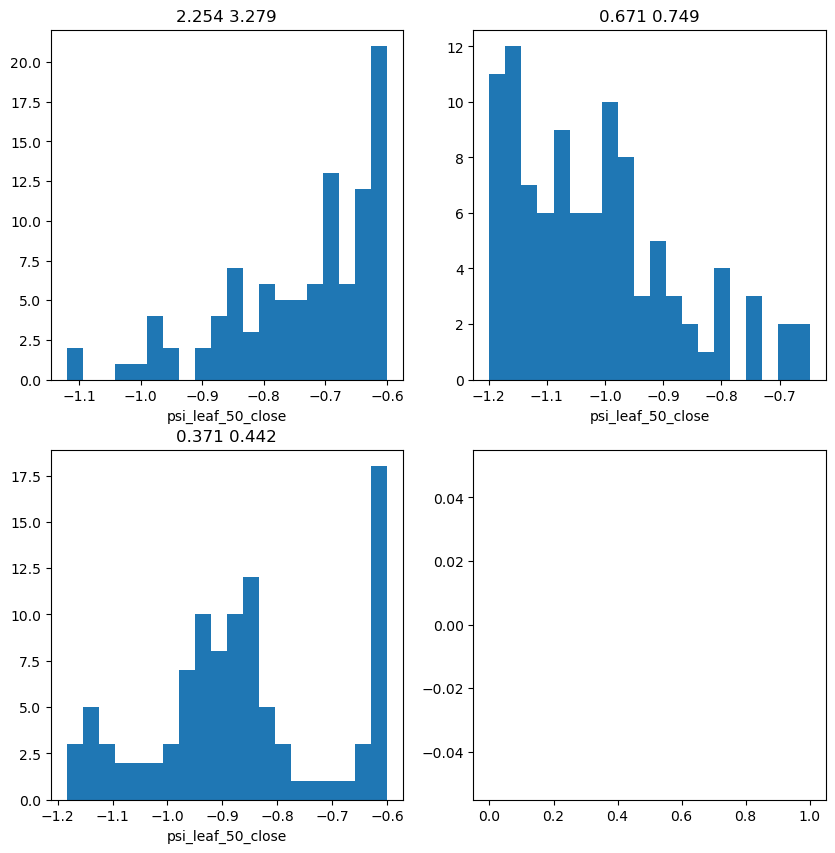

In [25]:
for nmax in [100,1000, 50000]:
    df_all = pd.read_csv(os.path.join(post_path, f"All_RMSE_{nmax}.csv"))
    for var in varsy:
        fig = plt.figure(figsize=(10,10))
        i = 1
        for sid in [-1, 0, 6, 7]:
            df_slice = df_all.loc[df_all['sid'] == sid, :]
            ax = fig.add_subplot(2,2,i)
            ax.hist(df_slice[var], alpha=1.0, bins = 20)
            if sid > -1:
                ax.set_title(f"{np.round(df_slice[f't{sid}'].iloc[0], 3)} {np.round(df_slice[f't{sid}'].iloc[-1], 3)}")
            else:
                ax.set_title(f"{np.round(df_slice[f'alive_mean'].iloc[0], 3)} {np.round(df_slice[f'alive_mean'].iloc[-1], 3)}") 
            ax.set_xlabel(var)
            i+=1
        plt.savefig(f"{post_path}/mean_hist_{var}_{nmax}.png")
        plt.close(fig)

In [ ]:
df_29 = pd.read_csv("/Net/Groups/BSI/scratch/ppapastefanou/simulations/SimPHony/swiss_cc/29_ex_con_2025_full_logit_mean_one_wcont_TLP/post/aggregated_out.csv")

In [10]:
df_slice = df_all.loc[df_all['sid'] == 6, :]
df_slice

,Unnamed: 0.1,Unnamed: 0,id,root_area_index,canopy_height,dts,dts_input,verbose,max_psi_leaf_change_per_hour,minimum_psi_leaf_multiplier,...,t7,t8,t9,t10,t11,t12,t13,alive_mean,alpha,sid
51200,0,8578,8578,10.847951,35,1800.0,1800,False,1.0,1.75,...,1.553469,5.236902,5.394322,3.055615,3.248450,3.036179,3.011013,3.429648,0.140989,6
51201,0,4296,4296,8.366065,35,1800.0,1800,False,1.0,1.75,...,1.492915,5.354582,5.512966,3.128780,3.326994,3.107242,3.084682,3.510077,0.246303,6
51202,0,14956,14956,11.676291,35,1800.0,1800,False,1.0,1.75,...,1.581331,5.404121,5.562898,3.160492,3.359075,3.141473,3.116372,3.545713,0.091699,6
51203,0,9422,9422,8.338299,35,1800.0,1800,False,1.0,1.75,...,1.516755,5.147591,5.304247,3.000237,3.191253,2.978592,2.954693,3.368934,0.151734,6
51204,0,8153,8153,8.442149,35,1800.0,1800,False,1.0,1.75,...,1.489739,5.104682,5.260961,2.975044,3.166631,2.952346,2.930555,3.340438,0.159275,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76795,99,4187,4187,10.075114,35,1800.0,1800,False,1.0,1.75,...,1.368312,5.584539,5.744688,3.296635,3.501701,3.273036,3.248079,3.688476,0.271146,6
76796,96,7518,7518,10.971169,35,1800.0,1800,False,1.0,1.75,...,1.284093,5.529839,5.689582,3.266197,3.473776,3.244138,3.219365,3.655437,0.184981,6
76797,97,15356,15356,9.968089,35,1800.0,1800,False,1.0,1.75,...,1.278812,5.695539,5.856487,3.367460,3.577242,3.342821,3.321040,3.764861,0.104505,6
76798,98,13263,13263,8.373776,35,1800.0,1800,False,1.0,1.75,...,1.285731,5.210256,5.367451,3.072581,3.272576,3.047339,3.023576,3.441403,0.119917,6


In [11]:
df_all[df_all['sid']==0].describe()

,Unnamed: 0.1,Unnamed: 0,id,root_area_index,canopy_height,dts,dts_input,max_psi_leaf_change_per_hour,minimum_psi_leaf_multiplier,vmax25,...,t7,t8,t9,t10,t11,t12,t13,alive_mean,alpha,sid
count,25600.000000,25600.000000,25600.000000,25600.000000,25600.0,25600.0,25600.0,25600.0,25600.00,25600.000000,...,25600.000000,25600.000000,25600.000000,25600.000000,25600.000000,25600.000000,25600.000000,25600.000000,25600.000000,25600.0
mean,49.500000,9807.546523,9807.546523,9.942225,35.0,1800.0,1800.0,1.0,1.75,40.326147,...,1.176480,6.105133,6.779360,3.579822,3.783055,3.559136,3.486744,4.066150,0.158737,0.0
std,28.866634,5635.866871,5635.866871,1.156509,0.0,0.0,0.0,0.0,0.00,5.773579,...,0.046309,0.761117,0.671187,0.344331,0.354098,0.343817,0.340139,0.385612,0.086135,0.0
min,0.000000,0.000000,0.000000,8.000085,35.0,1800.0,1800.0,1.0,1.75,30.001768,...,0.971676,3.544656,3.904309,2.095215,2.259243,2.069728,2.018905,2.384073,0.000043,0.0
25%,24.750000,4915.750000,4915.750000,8.932772,35.0,1800.0,1800.0,1.0,1.75,35.316258,...,1.147788,5.911461,6.562231,3.495611,3.694122,3.475117,3.403054,3.971404,0.085383,0.0
50%,49.500000,9852.000000,9852.000000,9.923850,35.0,1800.0,1800.0,1.0,1.75,40.514941,...,1.181887,6.206878,6.899525,3.644035,3.847429,3.623225,3.549747,4.141190,0.163491,0.0
75%,74.250000,14688.250000,14688.250000,10.937156,35.0,1800.0,1800.0,1.0,1.75,45.319974,...,1.210906,6.548896,7.209367,3.779004,3.988370,3.758051,3.684938,4.293735,0.233365,0.0
max,99.000000,19530.000000,19530.000000,11.999738,35.0,1800.0,1800.0,1.0,1.75,49.999935,...,1.292587,7.725979,7.910411,4.345565,4.577128,4.323782,4.239675,4.882565,0.299980,0.0


In [20]:
df_all


,Unnamed: 0.1,Unnamed: 0,id,root_area_index,canopy_height,dts,dts_input,verbose,max_psi_leaf_change_per_hour,minimum_psi_leaf_multiplier,...,t7,t8,t9,t10,t11,t12,t13,alive_mean,alpha,sid
0,0,432,432,6.235730,35,1800.0,1800,False,1.0,1.75,...,0.598693,5.283934,5.441744,3.376535,3.601765,3.349162,3.328555,3.716113,0.170193,0
1,0,8848,8848,11.461902,35,1800.0,1800,False,1.0,1.75,...,0.527011,5.335943,5.494177,3.391604,3.617715,3.365623,3.344574,3.737700,0.230249,0
2,0,1462,1462,11.598271,35,1800.0,1800,False,1.0,1.75,...,0.466391,5.339464,5.497727,3.410620,3.638874,3.382377,3.361273,3.754465,0.272816,0
3,0,6794,6794,10.940131,35,1800.0,1800,False,1.0,1.75,...,0.693865,5.421565,5.580479,3.463595,3.690876,3.435918,3.415289,3.812033,0.020623,0
4,0,11670,11670,9.456664,35,1800.0,1800,False,1.0,1.75,...,1.937337,1.800356,2.929325,1.605221,1.721678,1.557541,1.464852,1.799575,0.077778,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,5,15424,15424,11.681273,35,1800.0,1800,False,1.0,1.75,...,2.299193,0.775551,0.217474,0.651225,0.586525,0.694895,0.614556,0.569609,0.157409,-1
4996,4,3597,3597,6.827928,35,1800.0,1800,False,1.0,1.75,...,2.265148,0.717610,0.196223,0.644119,0.594159,0.690880,0.607171,0.569609,0.083331,-1
4997,1,3711,3711,7.332251,35,1800.0,1800,False,1.0,1.75,...,2.300205,0.690294,0.131719,0.655976,0.601251,0.713368,0.624640,0.569622,0.090783,-1
4998,2,12120,12120,7.850156,35,1800.0,1800,False,1.0,1.75,...,2.296932,0.700054,0.217442,0.648083,0.589603,0.697682,0.608196,0.569622,0.236434,-1
